In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
data = pd.read_csv("18-concrete_data.csv")

| Column             | Description                                                                                           |
|--------------------|-------------------------------------------------------------------------------------------------------|
| Cement             | The primary binding material in the concrete mixture. It provides the fundamental strength of concrete. |
| Blast Furnace Slag | A supplementary cementitious material partially replacing cement. It improves durability and workability. |
| Fly Ash            | A by-product from power plants used as a cement replacement. Enhances strength and reduces environmental impact. |
| Water              | The amount of water required for cement hydration. Determines workability and consistency of concrete. |
| Superplasticizer   | A chemical admixture that increases fluidity. Allows lower water content while maintaining workability. |
| Coarse Aggregate   | Gravel or crushed stone particles. Provides volume, strength, and stability to the concrete structure. |
| Fine Aggregate     | Sand or stone dust. Fills voids between coarse particles and improves cohesion in the mixture. |
| Age (Days)         | The curing time of the specimen in days. Strength generally increases with age due to ongoing hydration. |
| Concrete Strength  | The compressive strength of concrete (measured in MPa). A key indicator of concrete quality and load capacity. |


In [44]:
data

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [45]:
data.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [47]:
data.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [48]:
data.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [49]:
data.corr()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
Cement,1.000000,-0.275216,-0.397467,-0.081587,0.092386,-0.109349,-0.222718,0.081946,0.497832
Blast Furnace Slag,-0.275216,1.000000,-0.323580,0.107252,0.043270,-0.283999,-0.281603,-0.044246,0.134829
Fly Ash,-0.397467,-0.323580,1.000000,-0.256984,0.377503,-0.009961,0.079108,-0.154371,-0.105755
Water,-0.081587,0.107252,-0.256984,1.000000,-0.657533,-0.182294,-0.450661,0.277618,-0.289633
Superplasticizer,0.092386,0.043270,0.377503,-0.657533,1.000000,-0.265999,0.222691,-0.192700,0.366079
Coarse Aggregate,-0.109349,-0.283999,-0.009961,-0.182294,-0.265999,1.000000,-0.178481,-0.003016,-0.164935
Fine Aggregate,-0.222718,-0.281603,0.079108,-0.450661,0.222691,-0.178481,1.000000,-0.156095,-0.167241
Age,0.081946,-0.044246,-0.154371,0.277618,-0.192700,-0.003016,-0.156095,1.000000,0.328873
Strength,0.497832,0.134829,-0.105755,-0.289633,0.366079,-0.164935,-0.167241,0.328873,1.000000


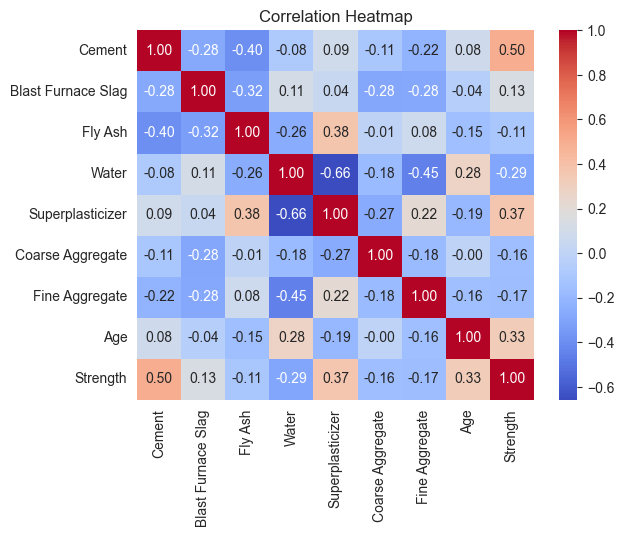

In [50]:
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

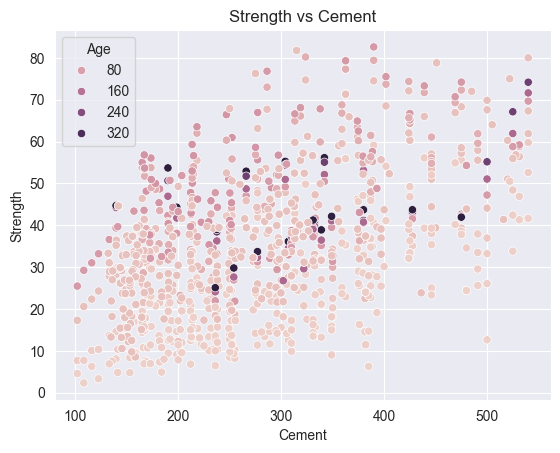

In [51]:
sns.scatterplot(data=data, x="Cement", y="Strength", hue="Age")
plt.title('Strength vs Cement')
plt.show()

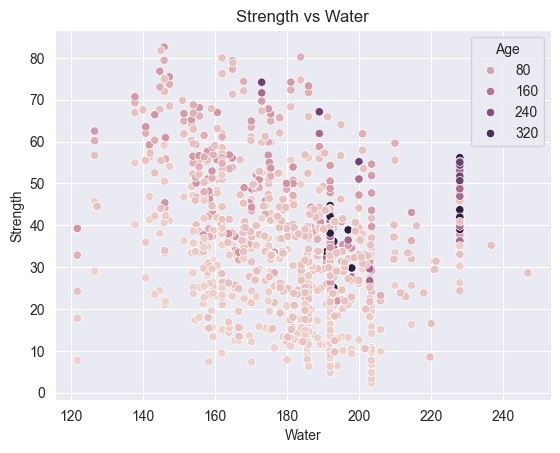

In [52]:
sns.scatterplot(data=data, x="Water", y="Strength", hue="Age")
plt.title('Strength vs Water')
plt.show()

In [53]:
X = data.drop("Strength", axis=1)
y = data["Strength"]

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [55]:
#Scaler operation is not performed on tree structures.

In [56]:
#manuel gradient boosting
from sklearn.tree import DecisionTreeRegressor

In [57]:
#first weak learner
tree_reg1 = DecisionTreeRegressor(max_depth=3)
tree_reg1.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [58]:
y2 = y_train - tree_reg1.predict(X_train) # reducue

In [59]:
y2

919   -15.044359
641    -2.967000
535     2.098039
835   -10.123407
583    -2.334359
         ...    
85    -12.370889
667    -0.824359
156    32.845641
384   -22.701250
645     3.843000
Name: Strength, Length: 772, dtype: float64

In [60]:
# second weak learner

tree_reg2 = DecisionTreeRegressor(max_depth=4)
tree_reg2.fit(X_train, y2)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [61]:
y3 = y2 - tree_reg2.predict(X_train)

In [62]:
y3

919    -7.776773
641    -0.353441
535     9.365625
835    -4.303430
583    -3.033962
         ...    
85    -13.619595
667    -1.523962
156    19.985365
384   -15.433664
645     3.143397
Name: Strength, Length: 772, dtype: float64

In [63]:
#third weak learner

tree_reg3 = DecisionTreeRegressor(max_depth=4)
tree_reg3.fit(X_train, y3)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [64]:
y4 = y3 - tree_reg3.predict(X_train)

In [65]:
y4

919    -8.311212
641    -0.887880
535     8.831186
835    -0.209931
583    -0.406351
         ...    
85     -8.343638
667     1.103649
156     5.252000
384   -15.968103
645     5.771008
Name: Strength, Length: 772, dtype: float64

In [69]:
y_pred = sum(tree.predict(X_test) for tree in (tree_reg1, tree_reg2, tree_reg3))

In [70]:
y_pred

array([65.85439489, 28.00473602, 50.37702428, 33.41121182, 37.51107931,
        6.80869054, 33.41121182, 39.35908175, 37.51107931, 19.81785128,
       31.95400272, 35.77628769, 50.37702428, 40.90725143,  6.80869054,
       41.92750386, 63.86062634, 52.87223273, 29.87495516, 42.03414186,
       24.16450206, 19.81785128, 47.90026501, 21.01172244, 41.92750386,
       41.92750386, 63.86062634,  7.80748382, 61.15078798, 21.01172244,
       32.74437086, 28.78327411, 11.12064566,  8.98994195, 51.48305906,
       35.77628769, 42.75403378, 19.41615049, 33.41121182, 13.76899209,
       33.41121182, 41.25684442, 24.16450206, 25.22654633,  2.26795097,
       53.5390737 , 33.41121182,  6.80869054, 77.46596472, 13.61787967,
       33.41121182, 41.92750386, 29.87495516, 57.33810285, 24.87398766,
       33.41121182,  7.80748382, 44.79045937, 33.41121182, 33.41121182,
       13.61787967, 77.46596472, 38.76545445, 24.16450206, 13.76899209,
        7.80748382, 40.90725143, 32.0113235 , 32.0113235 , 35.77

In [72]:
from sklearn.metrics import r2_score
print("tree regression 3: ",r2_score(y_test, y_pred))

tree regression 3:  0.8159494658632221


In [73]:
tree_reg4 = DecisionTreeRegressor(max_depth=4)
tree_reg4.fit(X_train, y4)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [74]:
y_pred = sum(tree.predict(X_test) for tree in (tree_reg1, tree_reg2, tree_reg3, tree_reg4))

In [76]:
print("tree regression 4: ",r2_score( y_test, y_pred))

tree regression 4:  0.8164029936095349


In [77]:
# Model

In [78]:
from sklearn.ensemble import GradientBoostingRegressor

In [80]:
gbr = GradientBoostingRegressor(n_estimators=3, max_depth=3, learning_rate=0.1)

In [81]:
gbr.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,3
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


0.31671418229216797

In [83]:
gbr = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1)

In [84]:
gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_test)
r2_score(y_test, y_pred)

0.924730619815904

In [86]:
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html#sklearn.ensemble.GradientBoostingRegressor
# hyperparameter tuning

params = {
    'n_estimators': [100, 150, 200],
    "max_depth": [3, 5, 7],
    "loss": ["squared_error", "absolute_error", "huber", "quantile"],
    "learning_rate": [0.1, 0.01, 0.05]
}

In [87]:
from sklearn.model_selection import RandomizedSearchCV

In [88]:
rscv = RandomizedSearchCV(estimator=GradientBoostingRegressor(), param_distributions=params, cv=5, n_jobs=-1)

In [89]:
rscv.fit(X_train, y_train)

,estimator,GradientBoostingRegressor()
,param_distributions,"{'learning_rate': [0.1, 0.01, ...], 'loss': ['squared_error', 'absolute_error', ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 150, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [90]:
rscv.best_params_

{'n_estimators': 200, 'max_depth': 5, 'loss': 'huber', 'learning_rate': 0.1}

In [91]:
y_pred = rscv.predict(X_test)
r2_score(y_test, y_pred)

0.9519255144149208